In [1]:
# Import required libraries for data handling, numerical operations, and plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the 15-minute household dataset from Open Power System Data
df = pd.read_csv("data/household_data_15min_singleindex.csv")

print(df.shape)
df.head()

(153810, 71)


,utc_timestamp,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
0,2014-12-11T17:45:00Z,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11T18:00:00Z,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11T18:15:00Z,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11T18:30:00Z,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11T18:45:00Z,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Convert timestamp column to datetime and set it as the DataFrame index
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

In [4]:
# Use timestamp as index for time-series processing
df = df.set_index("utc_timestamp")

In [5]:
# Sort rows chronologically
df = df.sort_index()

In [6]:
print(df.index.dtype)
df.head()

datetime64[ns, UTC]


,cet_cest_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:45:00+00:00,2014-12-11T18:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T19:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,2014-12-11T19:15:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,2014-12-11T19:30:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,2014-12-11T19:45:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Initial attempt to construct household load directly from cumulative signals
# Note: this version is only exploratory and is not used in the final pipeline
residential_ids = [1, 2, 3, 4, 5, 6]
load_df = pd.DataFrame(index=df.index)
for i in residential_ids:
    grid_import_col = f"DE_KN_residential{i}_grid_import"
    pv_col = f"DE_KN_residential{i}_pv"
    grid_export_col = f"DE_KN_residential{i}_grid_export"

    grid_import = df[grid_import_col] if grid_import_col in df.columns else 0.0
    pv = df[pv_col] if pv_col in df.columns else 0.0
    grid_export = df[grid_export_col] if grid_export_col in df.columns else 0.0

    load_df[f"residential{i}_load"] = grid_import + pv - grid_export
    load_df.head()

In [8]:
load_df.describe()

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13779.846119,2017.367027,3733.514971,7611.200361,4690.002662,15442.822022
std,7420.930370,1276.663640,2179.448629,4300.431896,2612.395098,5262.700005
min,0.085000,0.000000,0.044000,0.013000,0.020000,6243.700000
25%,7929.616000,843.123250,1926.089500,4338.875500,2254.466000,11102.427000
50%,12720.016000,1988.908000,3637.930500,7114.778000,4758.691000,15420.064000
75%,21331.149500,3055.754250,5526.456750,11445.450000,7195.781500,20338.923000
max,25618.242000,4495.448000,8324.087000,15752.780000,8773.800000,24401.449000


In [9]:
load_df.max()

residential1_load    25618.242
residential2_load     4495.448
residential3_load     8324.087
residential4_load    15752.780
residential5_load     8773.800
residential6_load    24401.449
dtype: float64

In [10]:
load_df = load_df / 1000

In [11]:
load_df.describe()

,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
count,63487.000000,63190.000000,47612.000000,81435.000000,123211.000000,66755.000000
mean,13.779846,2.017367,3.733515,7.611200,4.690003,15.442822
std,7.420930,1.276664,2.179449,4.300432,2.612395,5.262700
min,0.000085,0.000000,0.000044,0.000013,0.000020,6.243700
25%,7.929616,0.843123,1.926090,4.338876,2.254466,11.102427
50%,12.720016,1.988908,3.637931,7.114778,4.758691,15.420064
75%,21.331149,3.055754,5.526457,11.445450,7.195781,20.338923
max,25.618242,4.495448,8.324087,15.752780,8.773800,24.401449


In [12]:
nan_summary = pd.DataFrame({
    "nan_count": load_df.isna().sum(),
    "nan_percent": 100 * load_df.isna().sum() / len(load_df)
})

nan_summary

,nan_count,nan_percent
residential1_load,90323,58.723750
residential2_load,90620,58.916845
residential3_load,106198,69.044926
residential4_load,72375,47.054808
residential5_load,30599,19.894025
residential6_load,87055,56.599051


In [13]:
# Preliminary household extraction based on the initial direct-load construction
# This block is exploratory and not part of the final pipeline
house_data = {}

for i in residential_ids:
    
    col = f"residential{i}_load"
    
    house_df = load_df[[col]].dropna().copy()
    
    house_df = house_df.rename(columns={col: "load"})
    
    house_data[i] = house_df

In [14]:
for i in residential_ids:
    
    print(f"House {i}")
    print(house_data[i].shape)
    print()

House 1
(63487, 1)

House 2
(63190, 1)

House 3
(47612, 1)

House 4
(81435, 1)

House 5
(123211, 1)

House 6
(66755, 1)



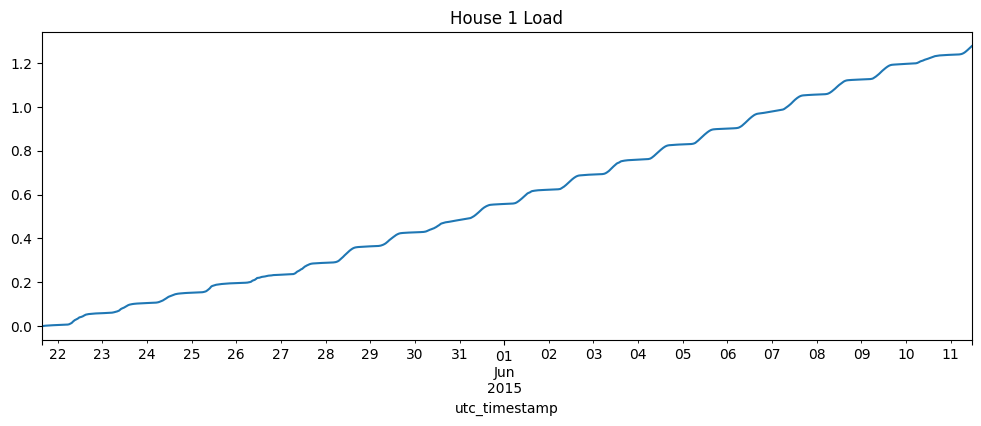

In [15]:
# Exploratory plot of the initial household load series before correcting cumulative measurements
house_data[1]["load"].iloc[:2000].plot(figsize=(12,4))
plt.title("House 1 Load")
plt.show()

In [16]:
# Sanity check for one household: convert cumulative energy signals into interval load using first differences
house_id = 1

# Select cumulative meter columns for one residential household
grid_import_col = f"DE_KN_residential{house_id}_grid_import"
pv_col = f"DE_KN_residential{house_id}_pv"
grid_export_col = f"DE_KN_residential{house_id}_grid_export"

house1 = df[[grid_import_col]].copy()

# Add PV column if available, otherwise use zero
if pv_col in df.columns:
    house1[pv_col] = df[pv_col]
else:
    house1[pv_col] = 0.0

# Add grid export column if available, otherwise use zero
if grid_export_col in df.columns:
    house1[grid_export_col] = df[grid_export_col]
else:
    house1[grid_export_col] = 0.0

house1 = house1.sort_index()
house1.head()

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
utc_timestamp,,,
2014-12-11 17:45:00+00:00,NaN,NaN,0.0
2014-12-11 18:00:00+00:00,NaN,NaN,0.0
2014-12-11 18:15:00+00:00,NaN,NaN,0.0
2014-12-11 18:30:00+00:00,NaN,NaN,0.0
2014-12-11 18:45:00+00:00,NaN,NaN,0.0


In [17]:
# Convert cumulative measurements into 15-minute interval values using first differences
house1_diff = house1.diff()
house1_diff.head()

,DE_KN_residential1_grid_import,DE_KN_residential1_pv,DE_KN_residential1_grid_export
utc_timestamp,,,
2014-12-11 17:45:00+00:00,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,0.0
2014-12-11 18:15:00+00:00,NaN,NaN,0.0
2014-12-11 18:30:00+00:00,NaN,NaN,0.0
2014-12-11 18:45:00+00:00,NaN,NaN,0.0


In [18]:
# Construct interval household load from grid import, PV generation, and grid export
house1_diff["load"] = (
    house1_diff[grid_import_col]
    + house1_diff[pv_col]
    - house1_diff[grid_export_col]
)

In [19]:
# Remove negative artifacts and NaN values created by differencing
house1_diff["load"] = house1_diff["load"].clip(lower=0)
# Keep only the final load column and drop the initial NaN row from differencing
house1_load = house1_diff[["load"]].dropna().copy()

house1_load.head()

,load
utc_timestamp,
2015-05-21 15:45:00+00:00,0.157
2015-05-21 16:00:00+00:00,0.273
2015-05-21 16:15:00+00:00,0.311
2015-05-21 16:30:00+00:00,0.280
2015-05-21 16:45:00+00:00,0.265


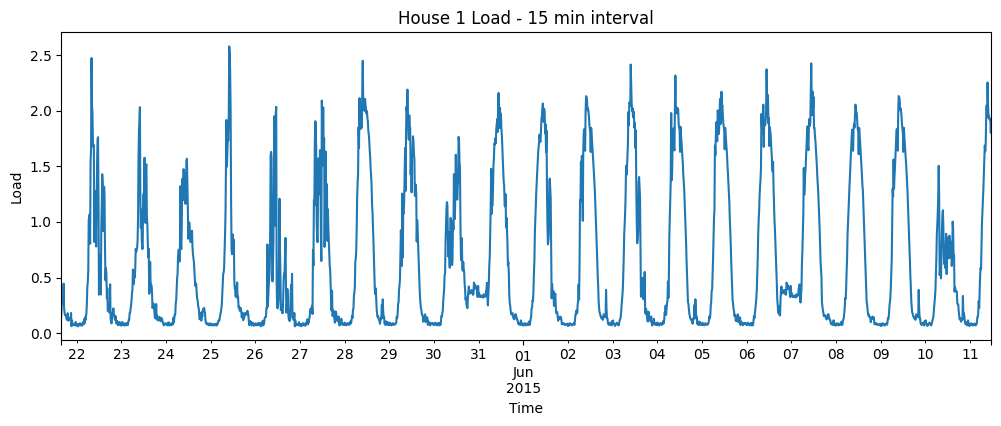

In [20]:
# Visual sanity check of the 15-minute household load profile
house1_load["load"].iloc[:2000].plot(figsize=(12, 4))
plt.title("House 1 Load - 15 min interval")
plt.xlabel("Time")
plt.ylabel("Load")
plt.show()

In [21]:
# Inspect descriptive statistics and verify regular 15-minute intervals
house1_load["load"].describe()

count    63486.000000
mean         0.403525
std          0.502228
min          0.029000
25%          0.105000
50%          0.165000
75%          0.449000
max          3.198000
Name: load, dtype: float64

In [22]:
house1_load.index.to_series().diff().value_counts().head()

utc_timestamp
0 days 00:15:00    63485
Name: count, dtype: int64

In [23]:
# Build final interval-based household load series for all residential households
house_data = {}

for house_id in residential_ids:

    # Define column names for the selected household
    grid_import_col = f"DE_KN_residential{house_id}_grid_import"
    pv_col = f"DE_KN_residential{house_id}_pv"
    grid_export_col = f"DE_KN_residential{house_id}_grid_export"

    # Start from cumulative grid import measurements
    house_df = df[[grid_import_col]].copy()

    # Add PV if available, otherwise fill with zero
    if pv_col in df.columns:
        house_df[pv_col] = df[pv_col]
    else:
        house_df[pv_col] = 0.0

    # Add grid export if available, otherwise fill with zero    
    if grid_export_col in df.columns:
        house_df[grid_export_col] = df[grid_export_col]
    else:
        house_df[grid_export_col] = 0.0
    
    house_df = house_df.sort_index()

    # Convert cumulative signals to interval energy values
    house_diff = house_df.diff()
    
    # Compute net household load
    house_diff["load"] = (
        house_diff[grid_import_col]
        + house_diff[pv_col]
        - house_diff[grid_export_col]
    )
    
    # Remove negative artifacts
    house_diff["load"] = house_diff["load"].clip(lower=0)
    
    # Keep only the final load series
    house_load = house_diff[["load"]].dropna().copy()
    
    house_data[house_id] = house_load

In [24]:
# Check the available number of samples for each household
for i in residential_ids:
    print(i, house_data[i].shape)

1 (63486, 1)
2 (63189, 1)
3 (47611, 1)
4 (81434, 1)
5 (123210, 1)
6 (66754, 1)


In [25]:
# Select one household for detailed forecasting experiments
house_id = 1
df_house = house_data[house_id].copy()

df_house.head()

,load
utc_timestamp,
2015-05-21 15:45:00+00:00,0.157
2015-05-21 16:00:00+00:00,0.273
2015-05-21 16:15:00+00:00,0.311
2015-05-21 16:30:00+00:00,0.280
2015-05-21 16:45:00+00:00,0.265


In [26]:
# Convert the household index to a timezone-aware datetime index
df_house.index = pd.to_datetime(df_house.index, utc=True)

In [27]:
type(df_house.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [28]:
# Create calendar-based time features from the timestamp index
df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)

df_house.head()

,load,hour,day_of_week,month,is_weekend
utc_timestamp,,,,,
2015-05-21 15:45:00+00:00,0.157,15,3,5,0
2015-05-21 16:00:00+00:00,0.273,16,3,5,0
2015-05-21 16:15:00+00:00,0.311,16,3,5,0
2015-05-21 16:30:00+00:00,0.280,16,3,5,0
2015-05-21 16:45:00+00:00,0.265,16,3,5,0


In [29]:
# Convert timestamps from UTC to local German time for meaningful calendar features
df_house.index = df_house.index.tz_convert("Europe/Berlin")
df_house.head()

,load,hour,day_of_week,month,is_weekend
utc_timestamp,,,,,
2015-05-21 17:45:00+02:00,0.157,15,3,5,0
2015-05-21 18:00:00+02:00,0.273,16,3,5,0
2015-05-21 18:15:00+02:00,0.311,16,3,5,0
2015-05-21 18:30:00+02:00,0.280,16,3,5,0
2015-05-21 18:45:00+02:00,0.265,16,3,5,0


In [30]:
# Recompute calendar features after converting to the local timezone
df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)

In [31]:
df_house.head()

,load,hour,day_of_week,month,is_weekend
utc_timestamp,,,,,
2015-05-21 17:45:00+02:00,0.157,17,3,5,0
2015-05-21 18:00:00+02:00,0.273,18,3,5,0
2015-05-21 18:15:00+02:00,0.311,18,3,5,0
2015-05-21 18:30:00+02:00,0.280,18,3,5,0
2015-05-21 18:45:00+02:00,0.265,18,3,5,0


In [32]:
# Create lag features to capture recent and daily historical load behavior
df_house["lag_1"] = df_house["load"].shift(1)    # 15 min ago
df_house["lag_4"] = df_house["load"].shift(4)    # 1 hour ago
df_house["lag_96"] = df_house["load"].shift(96)  # 24 hours ago

df_house.head()

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96
utc_timestamp,,,,,,,,
2015-05-21 17:45:00+02:00,0.157,17,3,5,0,NaN,NaN,NaN
2015-05-21 18:00:00+02:00,0.273,18,3,5,0,0.157,NaN,NaN
2015-05-21 18:15:00+02:00,0.311,18,3,5,0,0.273,NaN,NaN
2015-05-21 18:30:00+02:00,0.280,18,3,5,0,0.311,NaN,NaN
2015-05-21 18:45:00+02:00,0.265,18,3,5,0,0.280,0.157,NaN


In [33]:
# Drop rows with missing values introduced by lag features
df_house = df_house.dropna()
df_house.head()

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96
utc_timestamp,,,,,,,,
2015-05-22 17:45:00+02:00,0.584,17,4,5,0,0.475,1.318,0.157
2015-05-22 18:00:00+02:00,0.529,18,4,5,0,0.584,1.231,0.273
2015-05-22 18:15:00+02:00,0.313,18,4,5,0,0.529,0.754,0.311
2015-05-22 18:30:00+02:00,0.403,18,4,5,0,0.313,0.475,0.280
2015-05-22 18:45:00+02:00,0.200,18,4,5,0,0.403,0.584,0.265


In [34]:
# Create rolling mean features to capture short-term and daily load trends
df_house["rolling_mean_1h"] = df_house["load"].rolling(4).mean()
df_house["rolling_mean_24h"] = df_house["load"].rolling(96).mean()

df_house.head()

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
utc_timestamp,,,,,,,,,,
2015-05-22 17:45:00+02:00,0.584,17,4,5,0,0.475,1.318,0.157,NaN,NaN
2015-05-22 18:00:00+02:00,0.529,18,4,5,0,0.584,1.231,0.273,NaN,NaN
2015-05-22 18:15:00+02:00,0.313,18,4,5,0,0.529,0.754,0.311,NaN,NaN
2015-05-22 18:30:00+02:00,0.403,18,4,5,0,0.313,0.475,0.280,0.45725,NaN
2015-05-22 18:45:00+02:00,0.200,18,4,5,0,0.403,0.584,0.265,0.36125,NaN


In [35]:
# Drop rows with missing values introduced by rolling window features
df_house = df_house.dropna()

df_house.head()

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h
utc_timestamp,,,,,,,,,,
2015-05-23 17:30:00+02:00,0.642,17,5,5,1,0.374,0.682,0.475,0.53250,0.483885
2015-05-23 17:45:00+02:00,0.456,17,5,5,1,0.642,0.760,0.584,0.45650,0.482552
2015-05-23 18:00:00+02:00,0.431,18,5,5,1,0.456,0.354,0.529,0.47575,0.481531
2015-05-23 18:15:00+02:00,0.431,18,5,5,1,0.431,0.374,0.313,0.49000,0.482760
2015-05-23 18:30:00+02:00,0.381,18,5,5,1,0.431,0.642,0.403,0.42475,0.482531


In [36]:
df_house.shape

(63295, 10)

In [37]:
# Build a single-step 24-hour-ahead target for baseline model comparison
df_house["target"] = df_house["load"].shift(-96)
df_house = df_house.dropna()

df_house.head()

,load,hour,day_of_week,month,is_weekend,lag_1,lag_4,lag_96,rolling_mean_1h,rolling_mean_24h,target
utc_timestamp,,,,,,,,,,,
2015-05-23 17:30:00+02:00,0.642,17,5,5,1,0.374,0.682,0.475,0.53250,0.483885,0.488
2015-05-23 17:45:00+02:00,0.456,17,5,5,1,0.642,0.760,0.584,0.45650,0.482552,0.426
2015-05-23 18:00:00+02:00,0.431,18,5,5,1,0.456,0.354,0.529,0.47575,0.481531,0.451
2015-05-23 18:15:00+02:00,0.431,18,5,5,1,0.431,0.374,0.313,0.49000,0.482760,0.440
2015-05-23 18:30:00+02:00,0.381,18,5,5,1,0.431,0.642,0.403,0.42475,0.482531,0.366


In [38]:
# Separate input features and target variable for single-step forecasting
X = df_house.drop(columns=["load", "target"])
y = df_house["target"]

print(X.shape)
print(y.shape)

(63199, 9)
(63199,)


In [39]:
# Split the dataset chronologically into train, validation, and test sets
n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44239, 9) (44239,)
Val: (9480, 9) (9480,)
Test: (9480, 9) (9480,)


In [40]:
# Define baseline regression models for single-step load forecasting
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

In [41]:
# Train and evaluate baseline models on the validation set
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

results = []

for name, model in models.items():
    
    # Train the model on the training split
    model.fit(X_train, y_train)
    
    # Generate validation predictions
    y_pred = model.predict(X_val)
    
    # Compute evaluation metrics
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    })
    
# Rank models by validation RMSE
results_df = pd.DataFrame(results).sort_values("RMSE")

results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000486 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44239, number of used features: 9
[LightGBM] [Info] Start training from score 0.444155


,model,MAE,RMSE
5,LightGBM,0.142061,0.256603
0,LinearRegression,0.153836,0.259809
1,Ridge,0.153840,0.259810
4,XGBoost,0.145673,0.265973
3,RandomForest,0.149123,0.267480
2,DecisionTree,0.192264,0.363251


In [42]:
# Visual comparison between actual and predicted values for the best single-step baseline model
best_model = models["LightGBM"]

y_val_pred = best_model.predict(X_val)

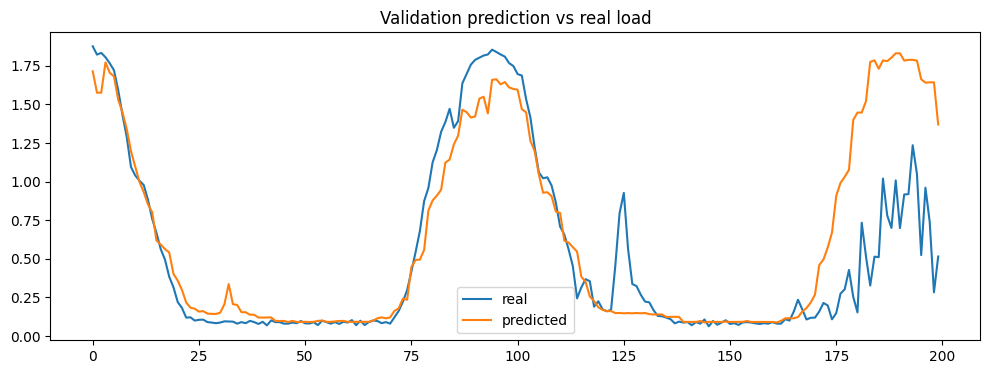

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(y_val.values[:200], label="real")
plt.plot(y_val_pred[:200], label="predicted")

plt.legend()
plt.title("Validation prediction vs real load")
plt.show()

In [44]:
# Build a direct multi-step target matrix for the next 24 hours (96 steps)
horizon = 96

y_multi = pd.DataFrame(index=df_house.index)

for h in range(1, horizon + 1):
    y_multi[f"target_t+{h}"] = df_house["load"].shift(-h)

y_multi.head()

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+87,target_t+88,target_t+89,target_t+90,target_t+91,target_t+92,target_t+93,target_t+94,target_t+95,target_t+96
utc_timestamp,,,,,,,,,,,,,,,,,,,,,
2015-05-23 17:30:00+02:00,0.456,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,...,0.819,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488
2015-05-23 17:45:00+02:00,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,...,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426
2015-05-23 18:00:00+02:00,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,...,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451
2015-05-23 18:15:00+02:00,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,...,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440
2015-05-23 18:30:00+02:00,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,...,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366


In [45]:
# Align input features with the multi-step targets and remove incomplete rows
data_multi = pd.concat([X, y_multi], axis=1)

data_multi = data_multi.dropna()

data_multi.shape

(63103, 105)

In [46]:
# Separate multi-step feature matrix and target matrix
X_multi = data_multi[X.columns]

y_multi = data_multi[y_multi.columns]

print(X_multi.shape)
print(y_multi.shape)

(63103, 9)
(63103, 96)


In [47]:
# Split the multi-step dataset chronologically into train, validation, and test sets
n = len(X_multi)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_multi.iloc[:train_end]
y_train = y_multi.iloc[:train_end]

X_val = X_multi.iloc[train_end:val_end]
y_val = y_multi.iloc[train_end:val_end]

X_test = X_multi.iloc[val_end:]
y_test = y_multi.iloc[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (44172, 9) (44172, 96)
Val: (9465, 9) (9465, 96)
Test: (9466, 9) (9466, 96)


In [48]:
# Train a baseline multi-output LightGBM model for direct 24-hour forecasting
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor

multi_lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        random_state=42
    )
)

multi_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000936 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 9
[LightGBM] [Info] Start training from score 0.443631
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1321
[LightGBM] [Info] Number of data points in the train set: 44172, number of used features: 9
[LightGBM] [Info] Start training from score 0.443624
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001768 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough,

MultiOutputRegressor(estimator=LGBMRegressor(random_state=42))

In [49]:
# Generate validation predictions for all 96 future time steps
y_val_pred = multi_lgbm.predict(X_val)

print(y_val_pred.shape)

(9465, 96)


In [50]:
# Evaluate the overall multi-step forecasting performance on the validation set
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.14562398642374758
RMSE: 0.2621290487106149


In [51]:
# Compute the forecasting error separately for each prediction horizon
mae_per_step = []

for h in range(96):
    mae_h = mean_absolute_error(y_val.iloc[:, h], y_val_pred[:, h])
    mae_per_step.append(mae_h)

mae_per_step[:10]

[0.07678865131346599,
 0.09077705632131376,
 0.09821806656499613,
 0.10546376694976596,
 0.1114935409639087,
 0.11587015944236964,
 0.12150703687728699,
 0.12402506629709684,
 0.12732681114650765,
 0.13133319004290878]

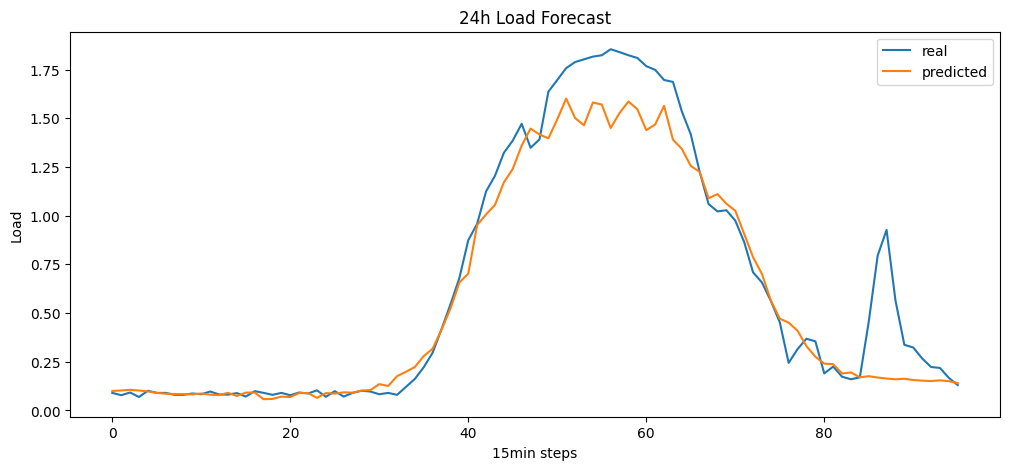

In [52]:
# Plot one full 24-hour forecast against the true load profile
import matplotlib.pyplot as plt

sample = 200

plt.figure(figsize=(12,5))

plt.plot(y_val.iloc[sample].values, label="real")
plt.plot(y_val_pred[sample], label="predicted")

plt.title("24h Load Forecast")
plt.xlabel("15min steps")
plt.ylabel("Load")
plt.legend()

plt.show()

In [53]:
# Define a small hyperparameter search space for the multi-output LightGBM model
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

param_grid = [
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": 10,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    }
]

# Train and evaluate all hyperparameter configurations on the validation set
tuning_results = []

for i, params in enumerate(param_grid, start=1):
    print(f"Running config {i}/{len(param_grid)} ...")
    
    model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=42,
            verbosity=-1,
            **params
        )
    )
    
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)
    
    mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))
    
    row = params.copy()
    row["MAE"] = mae
    row["RMSE"] = rmse
    tuning_results.append(row)

tuning_results_df = pd.DataFrame(tuning_results).sort_values("RMSE")
tuning_results_df

Running config 1/4 ...
Running config 2/4 ...
Running config 3/4 ...
Running config 4/4 ...


,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,MAE,RMSE
0,100,0.05,31,-1,20,1.0,1.0,0.144854,0.257048
2,200,0.03,63,-1,20,0.8,0.8,0.144374,0.258253
1,200,0.05,31,-1,20,1.0,1.0,0.145392,0.261572
3,300,0.03,63,10,30,0.8,0.8,0.145480,0.262003


In [54]:
# Retrain the final model using the best hyperparameters on the combined train and validation sets
from sklearn.multioutput import MultiOutputRegressor
from lightgbm import LGBMRegressor

# Combine train and validation data for final training
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

final_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        verbosity=-1
    )
)

final_model.fit(X_train_full, y_train_full)

MultiOutputRegressor(estimator=LGBMRegressor(learning_rate=0.05,
                                             random_state=42, verbosity=-1))

In [55]:
# Evaluate the final tuned model on the unseen test set
y_test_pred = final_model.predict(X_test)

mae_test = mean_absolute_error(y_test.values.flatten(), y_test_pred.flatten())
rmse_test = np.sqrt(mean_squared_error(y_test.values.flatten(), y_test_pred.flatten()))

print("TEST MAE:", mae_test)
print("TEST RMSE:", rmse_test)

TEST MAE: 0.11199436810003087
TEST RMSE: 0.20007847853954125


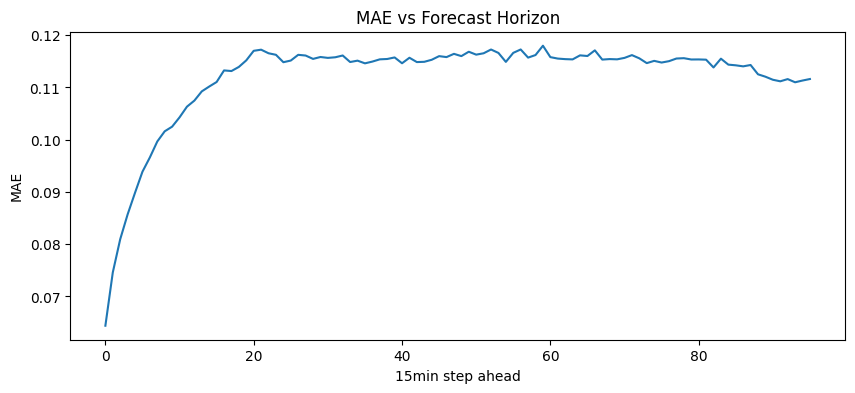

In [56]:
# Analyze the forecasting error across the full 24-hour prediction horizon on the test set
mae_per_step_test = []

for h in range(96):
    mae_h = mean_absolute_error(y_test.iloc[:, h], y_test_pred[:, h])
    mae_per_step_test.append(mae_h)

plt.figure(figsize=(10,4))
plt.plot(mae_per_step_test)
plt.title("MAE vs Forecast Horizon")
plt.xlabel("15min step ahead")
plt.ylabel("MAE")
plt.show()

In [57]:
# Save the final trained load forecasting model for later integration into the HEMS pipeline
import joblib

joblib.dump(final_model, "models/load_forecast_model.pkl")

['models/load_forecast_model.pkl']

In [58]:
# Load the saved model to verify persistence and future reusability
model = joblib.load("models/load_forecast_model.pkl")

In [59]:
# Define a helper function that returns the next 24-hour load forecast from one feature row
def predict_next_24h_load(model, feature_row):
    
    pred = model.predict(feature_row)
    
    return pred.flatten()